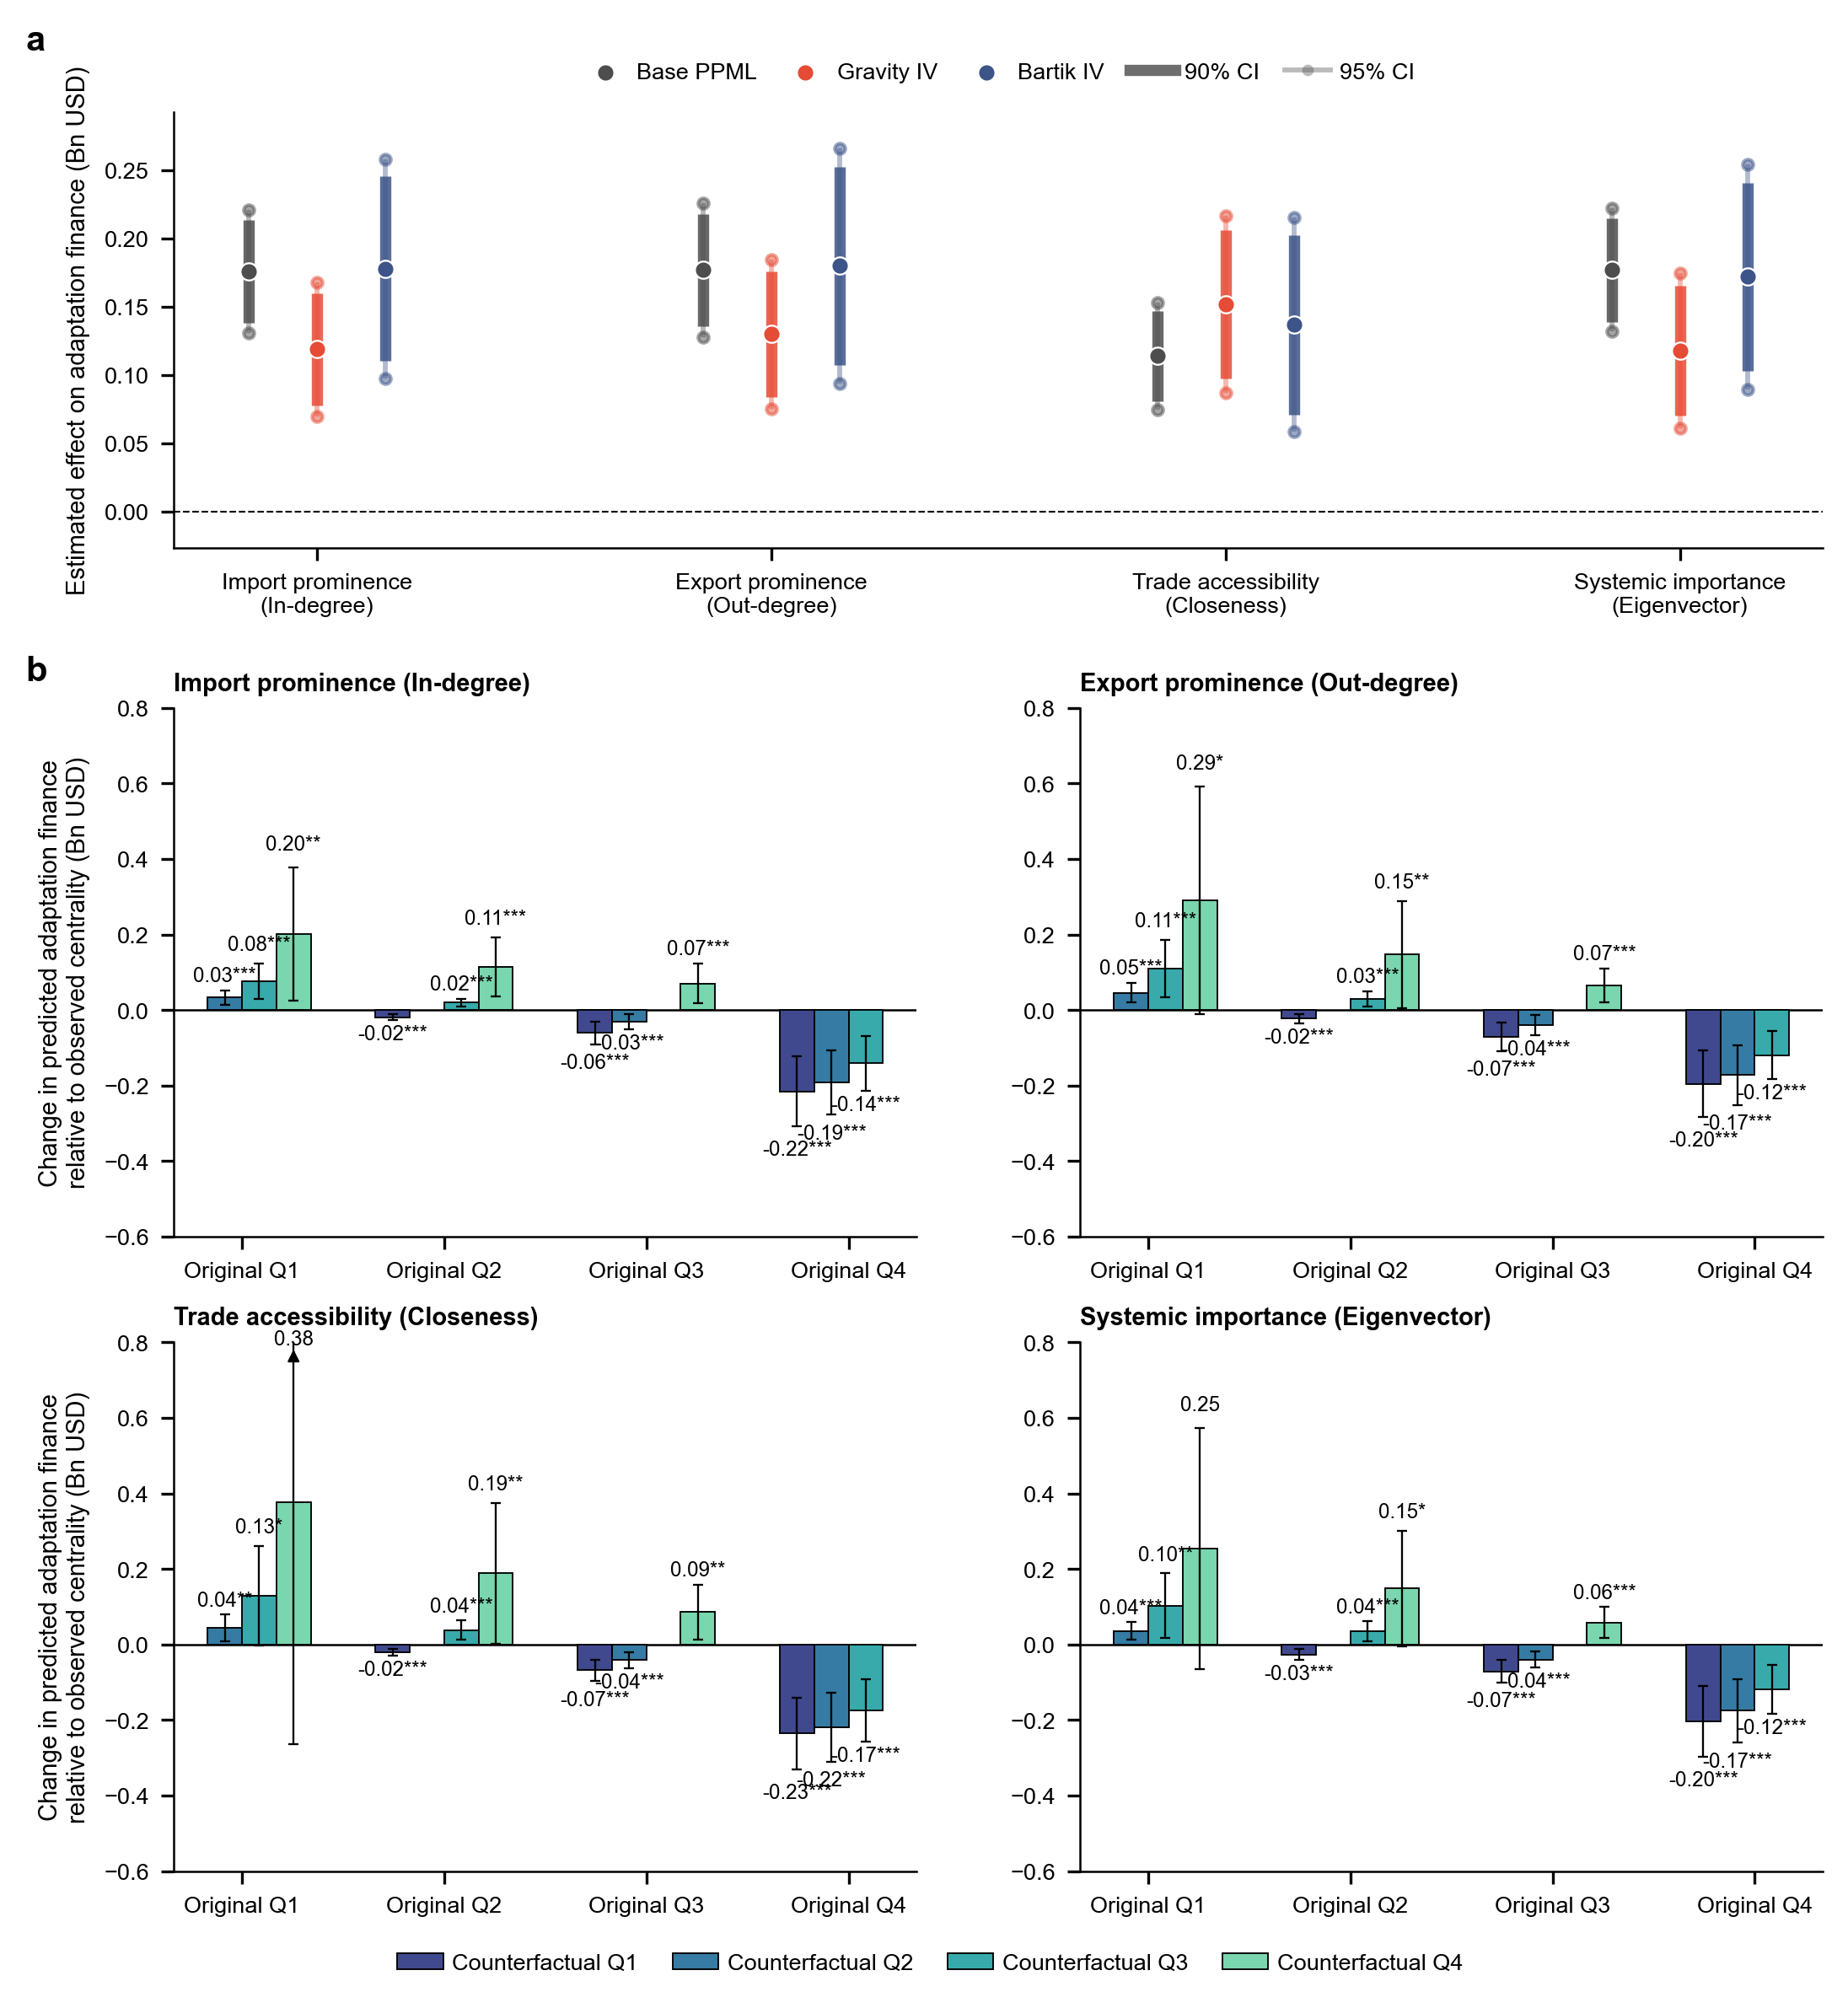

In [12]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# =========================================================
# 0. Output folder
# =========================================================
os.makedirs("Final", exist_ok=True)

# =========================================================
# 1. Global figure settings
# =========================================================
mm_to_inch = 1 / 25.4

# Nature full-width figure: 183 mm wide
fig_width = 183 * mm_to_inch
fig_height = 190 * mm_to_inch

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.titlesize": 7.5,
    "axes.labelsize": 7,
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 6.5,
    "axes.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "legend.fontsize": 6.5,
    "figure.dpi": 300,
    "lines.linewidth": 0.6,
})

# =========================================================
# 2. Panel a: coefficient plot functions
# =========================================================
def extract_model_data(file_path, model_name, col_mapping):
    """Extract coefficients and standard errors from esttab-style CSV files."""
    if not os.path.exists(file_path):
        print(f"⚠️ File not found: {file_path}")
        return pd.DataFrame()

    df_raw = pd.read_csv(file_path, dtype=str)

    def clean_val(val):
        if pd.isna(val):
            return np.nan

        val = (
            str(val)
            .replace("*", "")
            .replace("(", "")
            .replace(")", "")
            .replace("=", "")
            .replace('"', "")
            .strip()
        )

        try:
            return float(val)
        except ValueError:
            return np.nan

    extracted_data = []
    first_col_name = df_raw.columns[0]

    for cent, col_idx in col_mapping.items():

        mask = df_raw[first_col_name].str.contains(
            cent,
            case=False,
            na=False
        )

        if not mask.any():
            print(f"⚠️ Could not find {cent} in {file_path}")
            continue

        coef_row_idx = df_raw[mask].index[0]
        se_row_idx = coef_row_idx + 1

        try:
            coef = clean_val(df_raw.iloc[coef_row_idx, col_idx])
            se = clean_val(df_raw.iloc[se_row_idx, col_idx])

            if pd.notna(coef) and pd.notna(se):
                extracted_data.append({
                    "Centrality": cent,
                    "Model": model_name,
                    "Coefficient": coef,
                    "SE": se
                })

        except IndexError:
            pass

    return pd.DataFrame(extracted_data)


def plot_panel_a(ax):
    """Plot panel a: baseline and IV coefficient estimates."""

    col_mapping = {
        "In-Degree": 1,
        "Out-Degree": 2,
        "Closeness": 3,
        "Eigenvector": 4
    }

    df_base = extract_model_data(
        "../regression_results_5_centrality_lagged_MA3_PPML.csv",
        "Base PPML",
        col_mapping
    )

    df_gravity = extract_model_data(
        "../regression_results_5_centrality_GravityIV_CF_Bootstrap_Adaptation.csv",
        "Gravity IV",
        col_mapping
    )

    df_bartik = extract_model_data(
        "../regression_results_5_centrality_BartikIV_CF_Bootstrap_Adaptation.csv",
        "Bartik IV",
        col_mapping
    )

    df = pd.concat(
        [df_base, df_gravity, df_bartik],
        ignore_index=True
    )

    if df.empty:
        raise ValueError("No data extracted for panel a.")

    df["Error_95"] = 1.96 * df["SE"]
    df["Error_90"] = 1.645 * df["SE"]

    colors_a = {
        "Base PPML": "#4D4D4D",
        "Gravity IV": "#E64B35",
        "Bartik IV": "#3C5488"
    }

    offsets = {
        "Base PPML": -0.15,
        "Gravity IV": 0,
        "Bartik IV": 0.15
    }

    cent_order = [
        "In-Degree",
        "Out-Degree",
        "Closeness",
        "Eigenvector"
    ]

    label_mapping_a = {
        "In-Degree": "Import prominence\n(In-degree)",
        "Out-Degree": "Export prominence\n(Out-degree)",
        "Closeness": "Trade accessibility\n(Closeness)",
        "Eigenvector": "Systemic importance\n(Eigenvector)"
    }

    x_base = np.arange(len(cent_order))

    for model in ["Base PPML", "Gravity IV", "Bartik IV"]:

        subset = df[df["Model"] == model].copy()

        if subset.empty:
            continue

        subset["Centrality"] = pd.Categorical(
            subset["Centrality"],
            categories=cent_order,
            ordered=True
        )

        subset = subset.sort_values("Centrality")
        x_pos = x_base + offsets[model]

        y_means = subset["Coefficient"]
        y_mins_95 = subset["Coefficient"] - subset["Error_95"]
        y_maxs_95 = subset["Coefficient"] + subset["Error_95"]
        y_mins_90 = subset["Coefficient"] - subset["Error_90"]
        y_maxs_90 = subset["Coefficient"] + subset["Error_90"]

        # 95% CI
        ax.vlines(
            x=x_pos,
            ymin=y_mins_95,
            ymax=y_maxs_95,
            color=colors_a[model],
            linewidth=1.4,
            alpha=0.40,
            zorder=1
        )

        ax.scatter(
            x_pos,
            y_mins_95,
            color=colors_a[model],
            s=9,
            alpha=0.50,
            zorder=2
        )

        ax.scatter(
            x_pos,
            y_maxs_95,
            color=colors_a[model],
            s=9,
            alpha=0.50,
            zorder=2
        )

        # 90% CI
        ax.vlines(
            x=x_pos,
            ymin=y_mins_90,
            ymax=y_maxs_90,
            color=colors_a[model],
            linewidth=3.2,
            alpha=0.85,
            zorder=3
        )

        # Point estimate
        ax.scatter(
            x_pos,
            y_means,
            color=colors_a[model],
            s=24,
            edgecolor="white",
            linewidth=0.55,
            zorder=4,
            label=model
        )

    ax.axhline(
        y=0,
        color="black",
        linestyle="--",
        linewidth=0.5,
        zorder=0
    )

    ax.set_xticks(x_base)
    ax.set_xticklabels(
        [label_mapping_a[cent] for cent in cent_order]
    )

    ax.set_ylabel(
        "Estimated effect on adaptation finance (Bn USD)"
    )

    ax.margins(y=0.1)
    ax.grid(False)

    # Legend: models + confidence intervals
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    model_handles = list(by_label.values())
    model_labels = list(by_label.keys())

    ci_handles = [
        Line2D(
            [0], [0],
            color="#555555",
            lw=3.2,
            alpha=0.85,
            label="90% CI"
        ),
        Line2D(
            [0], [0],
            color="#555555",
            lw=1.4,
            alpha=0.40,
            marker="o",
            markersize=3.3,
            markeredgewidth=0,
            label="95% CI"
        )
    ]

    ax.legend(
        model_handles + ci_handles,
        model_labels + [h.get_label() for h in ci_handles],
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=5,
        columnspacing=1.1,
        handletextpad=0.4
    )


# =========================================================
# 3. Panel b: counterfactual bar chart functions
# =========================================================
quartiles = ["Q1", "Q2", "Q3", "Q4"]
target_groups = [f"Target=Q{q}" for q in range(1, 5)]
colors = sns.color_palette("mako", 5)[1:5]

target_color_map = {
    "Target=Q1": colors[0],
    "Target=Q2": colors[1],
    "Target=Q3": colors[2],
    "Target=Q4": colors[3],
}

def extract_number(x):
    """Extract the first numeric value from a CSV cell."""
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if x in ["", ".", "nan", "NaN"]:
        return np.nan

    match = re.search(r"-?\d+\.\d+|-?\d+", x)

    if match:
        return float(match.group())

    return np.nan


def sig_stars(p):
    """Convert p-values into significance stars."""
    if pd.isna(p):
        return ""

    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"

    return ""


def normalise_text(x):
    """Standardise whitespace for robust CSV matching."""
    return re.sub(r"\s+", " ", str(x).strip())


def find_original_columns(raw):
    """Locate the original Q1–Q4 group columns."""

    header_row_idx = None

    for i in range(len(raw)):

        row_text = " ".join(
            normalise_text(x)
            for x in raw.iloc[i].astype(str).tolist()
        )

        if re.search(r"Original\s*=\s*Q1", row_text):
            header_row_idx = i
            break

    if header_row_idx is None:
        raise ValueError(
            "Could not find the row containing 'Original = Q1'."
        )

    original_cols = {}

    for col in raw.columns:

        value = normalise_text(raw.iloc[header_row_idx, col])

        for q in quartiles:
            if re.search(rf"Original\s*=\s*{q}", value):
                original_cols[q] = col

    missing = [q for q in quartiles if q not in original_cols]

    if missing:
        raise ValueError(
            f"Could not identify columns for: {missing}"
        )

    return original_cols


def find_row(raw, keyword_options):
    """Find a row using one of several possible labels."""

    label_col = raw.columns[0]
    labels = raw[label_col].astype(str).map(normalise_text)

    if isinstance(keyword_options, str):
        keyword_options = [keyword_options]

    for keyword in keyword_options:

        matched = raw[
            labels.str.contains(
                normalise_text(keyword),
                case=False,
                regex=False,
                na=False
            )
        ]

        if not matched.empty:
            return matched.index[0]

    return None


def parse_entry_threshold_cf_csv(file_path):
    """Parse a continuous entry-threshold 4×4 counterfactual CSV."""

    raw = pd.read_csv(file_path, header=None)

    raw = (
        raw.dropna(how="all")
        .dropna(axis=1, how="all")
        .reset_index(drop=True)
    )

    original_cols = find_original_columns(raw)

    diff_rows = {
        q: find_row(
            raw,
            [
                f"Change: target {q} boundary minus actual",
                f"Change: target {q} threshold minus actual",
                f"Change: target {q} minus actual",
            ]
        )
        for q in quartiles
    }

    se_rows = {
        q: find_row(
            raw,
            [
                f"SE: target {q} boundary minus actual",
                f"SE: target {q} threshold minus actual",
                f"SE: target {q} minus actual",
            ]
        )
        for q in quartiles
    }

    pval_rows = {
        q: find_row(
            raw,
            [
                f"P-value: target {q} boundary minus actual",
                f"P-value: target {q} threshold minus actual",
                f"P-value: target {q} minus actual",
            ]
        )
        for q in quartiles
    }

    missing_rows = []

    for q in quartiles:
        if diff_rows[q] is None:
            missing_rows.append(f"Change row for {q}")
        if se_rows[q] is None:
            missing_rows.append(f"SE row for {q}")
        if pval_rows[q] is None:
            missing_rows.append(f"P-value row for {q}")

    if missing_rows:
        raise ValueError(
            "Missing rows in CSV:\n" + "\n".join(missing_rows)
        )

    records = []

    for original in quartiles:

        col = original_cols[original]

        for target in quartiles:

            if original == target:
                records.append({
                    "Original": original,
                    "Target": f"Target={target}",
                    "Delta": 0.0,
                    "SE": np.nan,
                    "P_value": np.nan,
                    "Sig": "",
                    "Is_baseline": True
                })
                continue

            delta = extract_number(raw.iloc[diff_rows[target], col])
            se = extract_number(raw.iloc[se_rows[target], col])
            pval = extract_number(raw.iloc[pval_rows[target], col])

            records.append({
                "Original": original,
                "Target": f"Target={target}",
                "Delta": delta,
                "SE": se,
                "P_value": pval,
                "Sig": sig_stars(pval),
                "Is_baseline": False
            })

    df = pd.DataFrame(records)

    return df.dropna(subset=["Delta"]).reset_index(drop=True)


def plot_entry_threshold_grouped_bar(ax, df, show_ylabel=False, y_min=None, y_max=None):
    """Plot one panel of entry-threshold counterfactual results."""

    x = np.arange(len(quartiles))
    width = 0.17

    offsets = {
        "Target=Q1": -1.5 * width,
        "Target=Q2": -0.5 * width,
        "Target=Q3": 0.5 * width,
        "Target=Q4": 1.5 * width
    }

    max_abs_delta = np.nanmax(np.abs(df["Delta"].values))

    if np.isnan(max_abs_delta) or max_abs_delta == 0:
        max_abs_delta = 0.1

    base_pad = max(0.012, 0.030 * max_abs_delta)
    stagger_step = max(0.012, 0.030 * max_abs_delta)

    ax.axhline(
        0,
        color="black",
        linewidth=0.6,
        zorder=2
    )

    label_records = []

    for target in target_groups:

        sub = df[df["Target"] == target]

        for _, row in sub.iterrows():

            original = row["Original"]
            xpos = x[quartiles.index(original)] + offsets[target]

            height = row["Delta"]
            is_baseline = row["Is_baseline"]

            if is_baseline:
                continue

            ax.bar(
                xpos,
                height,
                width=width,
                color=target_color_map[target],
                edgecolor="black",
                linewidth=0.45,
                zorder=3
            )

            # if not pd.isna(row["SE"]):

            #     yerr = 1.96 * row["SE"]

            #     ax.errorbar(
            #         xpos,
            #         height,
            #         yerr=yerr,
            #         fmt="none",
            #         ecolor="black",
            #         elinewidth=0.55,
            #         capsize=1.8,
            #         zorder=4
            #     )

            if not pd.isna(row["SE"]):

                yerr = 1.96 * row["SE"]

                ci_low = height - yerr
                ci_high = height + yerr

                upper_truncated = (y_max is not None and ci_high > y_max)
                lower_truncated = (y_min is not None and ci_low < y_min)

                plot_low = ci_low if y_min is None else max(ci_low, y_min)
                plot_high = ci_high if y_max is None else min(ci_high, y_max)

                # 1. draw visible vertical line only
                ax.vlines(
                    xpos,
                    plot_low,
                    plot_high,
                    color="black",
                    linewidth=0.55,
                    zorder=4
                )

                # 2. add caps only when the CI end is fully visible
                cap_halfwidth = 0.025

                if not lower_truncated:
                    ax.hlines(
                        ci_low,
                        xpos - cap_halfwidth,
                        xpos + cap_halfwidth,
                        color="black",
                        linewidth=0.55,
                        zorder=4
                    )

                if not upper_truncated:
                    ax.hlines(
                        ci_high,
                        xpos - cap_halfwidth,
                        xpos + cap_halfwidth,
                        color="black",
                        linewidth=0.55,
                        zorder=4
                    )

                # 3. arrow at upper boundary if truncated upward
                if upper_truncated:
                    ax.annotate(
                        "",
                        xy=(xpos, y_max),
                        xytext=(xpos, y_max - 0.06),
                        arrowprops=dict(
                            arrowstyle="-|>",
                            color="black",
                            lw=0.55,
                            mutation_scale=7
                        ),
                        clip_on=False,
                        zorder=5
                    )

                # 4. arrow at lower boundary if truncated downward
                if lower_truncated:
                    ax.annotate(
                        "",
                        xy=(xpos, y_min),
                        xytext=(xpos, y_min + 0.06),
                        arrowprops=dict(
                            arrowstyle="-|>",
                            color="black",
                            lw=0.55,
                            mutation_scale=7
                        ),
                        clip_on=False,
                        zorder=5
                    )
            else:
                yerr = 0

            label_text = f"{height:.2f}{row['Sig']}"

            if height >= 0:
                if upper_truncated and y_max is not None:
                    base_y = y_max + 0.01
                    va = "top"
                else:
                    base_y = plot_high + base_pad
                    va = "bottom"
                direction = 1
                sign = "positive"
            else:
                if lower_truncated and y_min is not None:
                    base_y = y_min + 0.03
                    va = "bottom"
                else:
                    base_y = plot_low - base_pad
                    va = "top"
                direction = -1
                sign = "negative"


            label_records.append({
                "x": xpos,
                "base_y": base_y,
                "label": label_text,
                "va": va,
                "direction": direction,
                "sign": sign,
                "original": original
                })

    # Avoid overlapping labels within each original quartile
    if label_records:

        label_df = pd.DataFrame(label_records)

        for (original, sign), group in label_df.groupby(["original", "sign"]):

            if sign == "positive":
                group = group.sort_values("base_y", ascending=True)
            else:
                group = group.sort_values("base_y", ascending=False)

            for k, (_, item) in enumerate(group.iterrows()):

                y_final = (
                    item["base_y"]
                    + item["direction"] * k * stagger_step
                )

                ax.text(
                    item["x"],
                    y_final,
                    item["label"],
                    ha="center",
                    va=item["va"],
                    fontsize=5.8,
                    color="black",
                    zorder=6,
                    clip_on=False
                )

    ax.set_xticks(x)
    ax.set_xticklabels([f"Original {q}" for q in quartiles])

    if show_ylabel:
        ax.set_ylabel(
            "Change in predicted adaptation finance\n"
            "relative to observed centrality (Bn USD)"
        )

    ax.grid(False)


# =========================================================
# 4. Load panel b data
# =========================================================
file_map_b = {
    "In-degree": "../in_degree_continuous_entry_threshold_4x4_matrix.csv",
    "Out-degree": "../out_degree_continuous_entry_threshold_4x4_matrix.csv",
    "Closeness": "../closeness_continuous_entry_threshold_4x4_matrix.csv",
    "Eigenvector": "../eigenvector_continuous_entry_threshold_4x4_matrix.csv"
}

label_mapping_b = {
    "In-degree": "Import prominence (In-degree)",
    "Out-degree": "Export prominence (Out-degree)",
    "Closeness": "Trade accessibility (Closeness)",
    "Eigenvector": "Systemic importance (Eigenvector)"
}

data_map_b = {
    name: parse_entry_threshold_cf_csv(path)
    for name, path in file_map_b.items()
}


# =========================================================
# 5. Build the combined Figure 4
# =========================================================
fig = plt.figure(
    figsize=(fig_width, fig_height)
)

outer_grid = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[0.75, 2],
    hspace=0.2
)

# -------------------------
# Panel a
# -------------------------
ax_a = fig.add_subplot(outer_grid[0, 0])
plot_panel_a(ax_a)

ax_a.text(
    -0.09,
    1.20,
    "a",
    transform=ax_a.transAxes,
    fontsize=10,
    fontweight="bold",
    va="top",
    ha="left"
)

# -------------------------
# Panel b: 2 × 2 panels
# -------------------------
grid_b = outer_grid[1, 0].subgridspec(
    nrows=2,
    ncols=2,
    hspace=0.2,
    wspace=0.22
)

axes_b = [
    fig.add_subplot(grid_b[0, 0]),
    fig.add_subplot(grid_b[0, 1]),
    fig.add_subplot(grid_b[1, 0]),
    fig.add_subplot(grid_b[1, 1])
]

# Common y range across the four panel-b subfigures
# all_values = []

# for df_plot in data_map_b.values():

#     ci_upper = df_plot["Delta"] + 1.96 * df_plot["SE"].fillna(0)
#     ci_lower = df_plot["Delta"] - 1.96 * df_plot["SE"].fillna(0)

#     all_values.extend(ci_upper.dropna().tolist())
#     all_values.extend(ci_lower.dropna().tolist())

# if all_values:
#     y_tick_step = 0.2

#     actual_min = np.nanmin(all_values)
#     actual_max = np.nanmax(all_values)

#     y_min = np.floor(actual_min / y_tick_step) * y_tick_step
#     y_max = np.ceil(actual_max / y_tick_step) * y_tick_step

#     for ax in axes_b:
#         ax.set_ylim(y_min, y_max)
#         ax.set_yticks(
#             np.arange(y_min, y_max + 0.001, y_tick_step)
#         )

# Manual y-axis range for Panel b
y_min = -0.6
y_max = 0.8
y_tick_step = 0.2

for ax in axes_b:
    ax.set_ylim(y_min, y_max)
    ax.set_yticks(
        np.arange(y_min, y_max + 0.001, y_tick_step)
    )
for i, (name, df_plot) in enumerate(data_map_b.items()):

    plot_entry_threshold_grouped_bar(
        ax=axes_b[i],
        df=df_plot,
        show_ylabel=(i % 2 == 0),
        y_min=y_min,
        y_max=y_max
    )

    axes_b[i].set_title(
        label_mapping_b.get(name, name),
        loc="left",
        fontsize=7,
        fontweight="bold",
        pad=5
    )


# Panel b label
axes_b[0].text(
    -0.20,
    1.1,
    "b",
    transform=axes_b[0].transAxes,
    fontsize=10,
    fontweight="bold",
    va="top",
    ha="left"
)

# Panel b legend
handles_b = [
    Patch(
        facecolor=target_color_map[f"Target={q}"],
        edgecolor="black",
        linewidth=0.45,
        label=f"Counterfactual {q}"
    )
    for q in quartiles
]

fig.legend(
    handles=handles_b,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.005),
    columnspacing=1.5,
    handletextpad=0.4
)

# =========================================================
# 6. Final layout and export
# =========================================================
fig.subplots_adjust(
    left=0.085,
    right=0.99,
    top=0.99,
    bottom=0.06
)

output_filename_pdf = "Final/Fig.4.pdf"
output_filename_png = "Final/Fig.4.png"

fig.savefig(
    output_filename_pdf,
    format="pdf",
    bbox_inches="tight"
)

fig.savefig(
    output_filename_png,
    dpi=1200,
    bbox_inches="tight"
)

plt.show()